INVERTER 32nm CMOS data

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from tensorflow.keras import backend as K
import numpy as np

K.clear_session()

# Carregando scalers
scaler_x = joblib.load('../data/processed/dados_32nm_cmos/scaler_x.pkl')
scaler_y = joblib.load('../data/processed/dados_32nm_cmos/scaler_y.pkl')

# Carregando os dados

X_train_sc = pd.read_csv('../data/processed/dados_32nm_cmos/X_train_sc.csv')
X_val_sc   = pd.read_csv('../data/processed/dados_32nm_cmos/X_val_sc.csv')
Xte_sc     = pd.read_csv('../data/processed/dados_32nm_cmos/X_test_sc.csv')

y_train_sc = pd.read_csv('../data/processed/dados_32nm_cmos/y_train_sc.csv')
y_val_sc   = pd.read_csv('../data/processed/dados_32nm_cmos/y_val_sc.csv')
yte_sc     = pd.read_csv('../data/processed/dados_32nm_cmos/y_test_sc.csv')

print(f"Training set loaded: {X_train_sc.shape}")
print(f"Validation set loaded: {X_val_sc.shape}")
print(f"Test set loaded: {Xte_sc.shape}")

I0000 00:00:1776984242.054558   43373 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776984242.055014   43373 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776984242.093643   43373 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776984243.058415   43373 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Training set loaded: (64204, 7)
Validation set loaded: (31624, 7)
Test set loaded: (31943, 7)


### Plot Functions

In [2]:
plots_dir = "../figures/32nm_cmos/02_outputs/"

variables = ['TPHL', 'TPLH', 'CORRENT']

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

def scatter_plot_multi_output_regression_results(y_predi, y_real, target_names, fname, subtitle=None):
    y_pred = np.array(y_predi)
    y_true = np.array(y_real)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    if subtitle:
        fig.suptitle(subtitle, fontsize=13, fontweight='bold', y=1.02)
    
    for i in range(3):
        ax = axes[i]
        
        sns.scatterplot(x=y_true[:, i], y=y_pred[:, i], ax=ax, 
                        alpha=0.5, color='royalblue', edgecolor=None)
        
        low = min(y_true[:, i].min(), y_pred[:, i].min())
        high = max(y_true[:, i].max(), y_pred[:, i].max())
        ax.plot([low, high], [low, high], color='red', linestyle='--', lw=2, label='Ideal')
        

        r2 = r2_score(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        
        ax.set_title(f'{target_names[i]}\n$R^2 = {r2:.3f}$ | $RMSE = {rmse:.3f}$')
        ax.set_xlabel('Valores Reais ($y_{true}$)')
        ax.set_ylabel(r'Predições ($\hat{y}$)')
        ax.grid(True, linestyle=':', alpha=0.6)
        if i == 0: ax.legend()

    plt.tight_layout()
    plt.savefig(f"{plots_dir}{fname}.png", dpi=300, bbox_inches='tight') 
    plt.show()

def kde_plot_multi_output_regression_results(y_pred, y_real, target_names, fname, subtitle=None):
    y_pred_np = np.array(y_pred)
    y_val_np  = np.array(y_real)

    for i, var in enumerate(target_names):
        fig, ax = plt.subplots(1, 1, figsize=(10, 7))

        sns.kdeplot(data=y_pred_np[:, i], label='predicted', ax=ax, color='royalblue')
        sns.kdeplot(data=y_val_np[:, i],  label='true',      ax=ax, color='red')

        title = f'{subtitle}, {var}' if subtitle else var
        ax.set_title(title)
        ax.legend()

        plt.savefig(f"{plots_dir}/{fname}_{var}.png")
        plt.show()
        plt.close()

# Multi-layer Perceptron (MPL)
Neural network for supervised learning

Idea:
- Single-output model approach (Predicting one output at a time)
- Multi-output model approach (Predicting three outputs at the same time)

Metrics
- R² score (coefficient of determination) regression score function
- RMSE and MSE error metrics

In [3]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error
from sklearn.metrics import r2_score

In [4]:
scores = {}

In [5]:
def score(model, X, y, target_name, target_variable, target_set):
    pred = model.predict(X)
    r2 = r2_score(y, pred)
    rmse = root_mean_squared_error(y, pred)
    mse = mean_squared_error(y, pred)

    scores[target_name, target_variable, target_set] = {
        'r2': r2,
        'rmse': rmse,
        'mse': mse,
    }
    return scores[target_name, target_variable, target_set]

## Multi-layer Perceptron for Regression using Scikit-Learn

In [6]:
from sklearn.neural_network import MLPRegressor

mlp_regressor= MLPRegressor(activation='relu',
                            solver = 'adam',
                            max_iter=500,
                            shuffle=True,
                            validation_fraction=0.1,
                            n_iter_no_change=10,
                            hidden_layer_sizes=(100, ),
                            early_stopping = True,
                            random_state=42,
                            verbose=True
                           )

### Single-output models

#### Predicting TPHL

In [7]:
# Training
mlp_regressor.fit(X_train_sc, y_train_sc['tphl'])

Iteration 1, loss = 0.15237320
Validation score: 0.925342
Iteration 2, loss = 0.02146690
Validation score: 0.975782
Iteration 3, loss = 0.00706184
Validation score: 0.991706
Iteration 4, loss = 0.00294373
Validation score: 0.995403
Iteration 5, loss = 0.00183896
Validation score: 0.996948
Iteration 6, loss = 0.00132350
Validation score: 0.997474
Iteration 7, loss = 0.00102599
Validation score: 0.998232
Iteration 8, loss = 0.00081619
Validation score: 0.998583
Iteration 9, loss = 0.00067888
Validation score: 0.998788
Iteration 10, loss = 0.00057509
Validation score: 0.999004
Iteration 11, loss = 0.00050276
Validation score: 0.999074
Iteration 12, loss = 0.00043668
Validation score: 0.999220
Iteration 13, loss = 0.00039507
Validation score: 0.999256
Iteration 14, loss = 0.00035602
Validation score: 0.999372
Iteration 15, loss = 0.00031908
Validation score: 0.999418
Iteration 16, loss = 0.00029313
Validation score: 0.999461
Iteration 17, loss = 0.00027832
Validation score: 0.999445
Iterat

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [8]:
print(mlp_regressor.out_activation_)
print(mlp_regressor.loss_)

identity
0.00019990782067936497


In [9]:
# Validation
y_pred_sc = mlp_regressor.predict(X_val_sc)

In [10]:
# Validation R² score
mlp_regressor.score(X_val_sc, y_val_sc['tphl'])

0.9996557275862706

In [11]:
# Validation error
rmse = root_mean_squared_error(y_val_sc['tphl'], y_pred_sc)
mse = mean_squared_error(y_val_sc['tphl'], y_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.018585350948205393
clf: MLP, MSE 0.00034541526986795916


In [12]:
score(mlp_regressor, X_val_sc, y_val_sc['tphl'], 'mlp_S_SKL', 'tphl', 'val')

{'r2': 0.9996557275862706,
 'rmse': 0.018585350948205393,
 'mse': 0.00034541526986795916}

In [13]:
# Testing
y_test_pred_sc = mlp_regressor.predict(Xte_sc)

In [14]:
# Testing R² score
mlp_regressor.score(Xte_sc, yte_sc['tphl'])

0.9996425283681345

In [15]:
# Testing error
rmse = root_mean_squared_error(yte_sc['tphl'], y_test_pred_sc)
mse = mean_squared_error(yte_sc['tphl'], y_test_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.019029553731250225
clf: MLP, MSE 0.00036212391521053935


In [16]:
score(mlp_regressor, Xte_sc, yte_sc['tphl'], 'mlp_S_SKL', 'tphl', 'test')

{'r2': 0.9996425283681345,
 'rmse': 0.019029553731250225,
 'mse': 0.00036212391521053935}

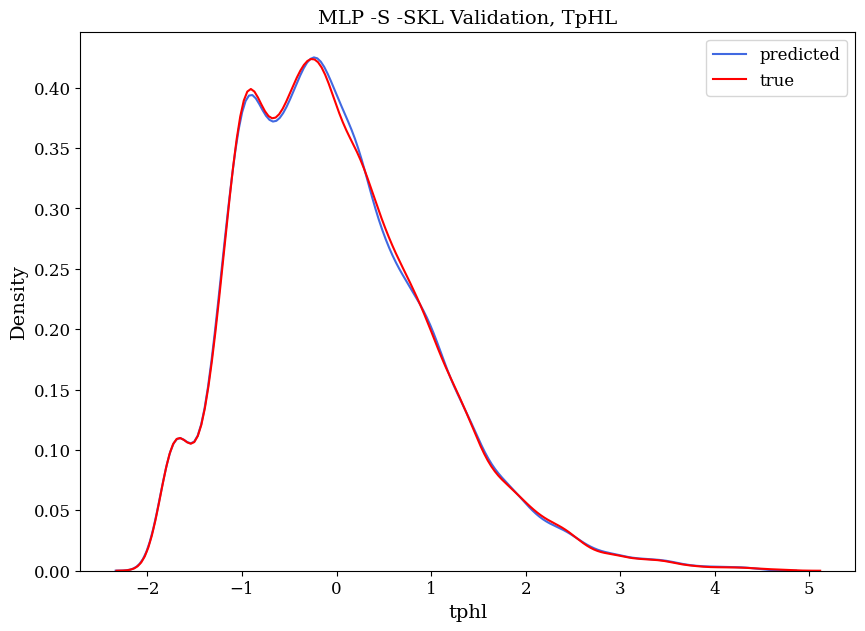

In [17]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['tphl'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, TpHL')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_SKL_VAL_TPHL.png")
plt.show()
plt.close()

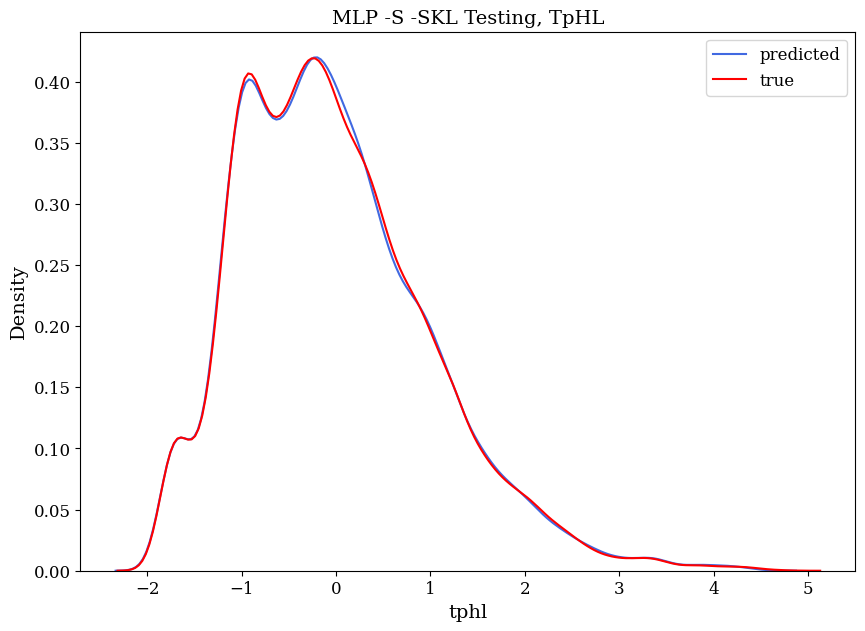

In [18]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc['tphl'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Testing, TpHL')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_SKL_TEST_TPHL.png")
plt.show()
plt.close()

#### Predicting TPLH

In [19]:
# Training
mlp_regressor.fit(X_train_sc, y_train_sc['tplh'])

Iteration 1, loss = 0.12928024
Validation score: 0.893096
Iteration 2, loss = 0.03370267
Validation score: 0.963444
Iteration 3, loss = 0.01172078
Validation score: 0.986993
Iteration 4, loss = 0.00457722
Validation score: 0.993827
Iteration 5, loss = 0.00240328
Validation score: 0.996306
Iteration 6, loss = 0.00145465
Validation score: 0.997655
Iteration 7, loss = 0.00096617
Validation score: 0.998317
Iteration 8, loss = 0.00072916
Validation score: 0.998652
Iteration 9, loss = 0.00059742
Validation score: 0.998930
Iteration 10, loss = 0.00052827
Validation score: 0.999026
Iteration 11, loss = 0.00048247
Validation score: 0.999092
Iteration 12, loss = 0.00045091
Validation score: 0.999134
Iteration 13, loss = 0.00043133
Validation score: 0.999184
Iteration 14, loss = 0.00040914
Validation score: 0.999223
Iteration 15, loss = 0.00039921
Validation score: 0.999229
Iteration 16, loss = 0.00038880
Validation score: 0.999269
Iteration 17, loss = 0.00038600
Validation score: 0.999303
Iterat

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [20]:
print(mlp_regressor.out_activation_)
print(mlp_regressor.loss_)

identity
0.000361401295658909


In [21]:
# Validation
y_pred_sc = mlp_regressor.predict(X_val_sc)

In [22]:
# Validation R² score
mlp_regressor.score(X_val_sc, y_val_sc['tplh'])

0.9992768533307875

In [23]:
# Validation error
rmse = root_mean_squared_error(y_val_sc['tplh'], y_pred_sc)
mse = mean_squared_error(y_val_sc['tplh'], y_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.026538579066803344
clf: MLP, MSE 0.0007042961788849726


In [24]:
score(mlp_regressor, X_val_sc, y_val_sc['tplh'], 'mlp_S_SKL', 'tplh', 'val')

{'r2': 0.9992768533307875,
 'rmse': 0.026538579066803344,
 'mse': 0.0007042961788849726}

In [25]:
# Testing
y_test_pred_sc = mlp_regressor.predict(Xte_sc)

In [26]:
# Testing R² score
mlp_regressor.score(Xte_sc, yte_sc['tplh'])

0.9992752050002677

In [27]:
# Testing error
rmse = root_mean_squared_error(yte_sc['tplh'], y_test_pred_sc)
mse = mean_squared_error(yte_sc['tplh'], y_test_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.02688546999249926
clf: MLP, MSE 0.000722828496717578


In [28]:
score(mlp_regressor, Xte_sc, yte_sc['tplh'], 'mlp_S_SKL', 'tplh', 'test')

{'r2': 0.9992752050002677,
 'rmse': 0.02688546999249926,
 'mse': 0.000722828496717578}

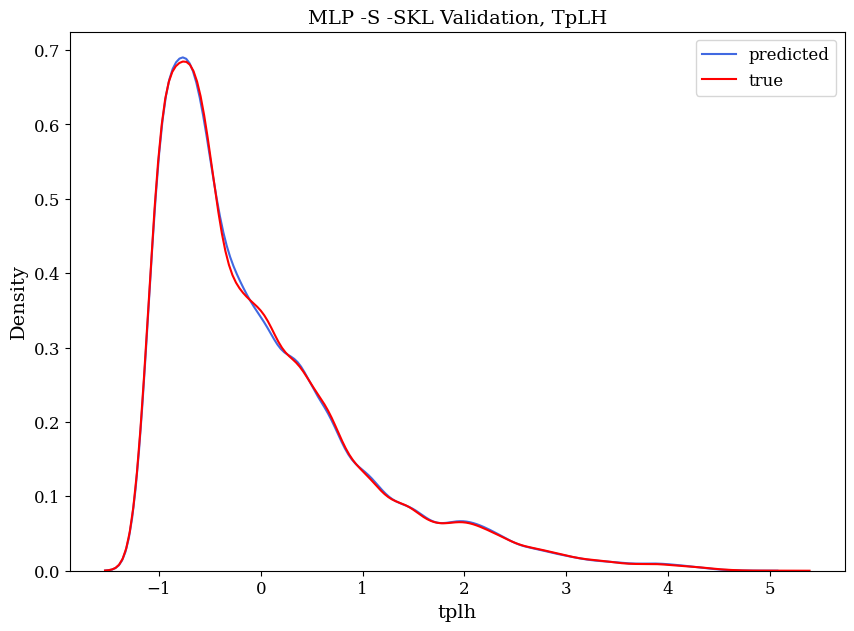

In [29]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['tplh'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, TpLH')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_SKL_VAL_TPLH.png")
plt.show()
plt.close()

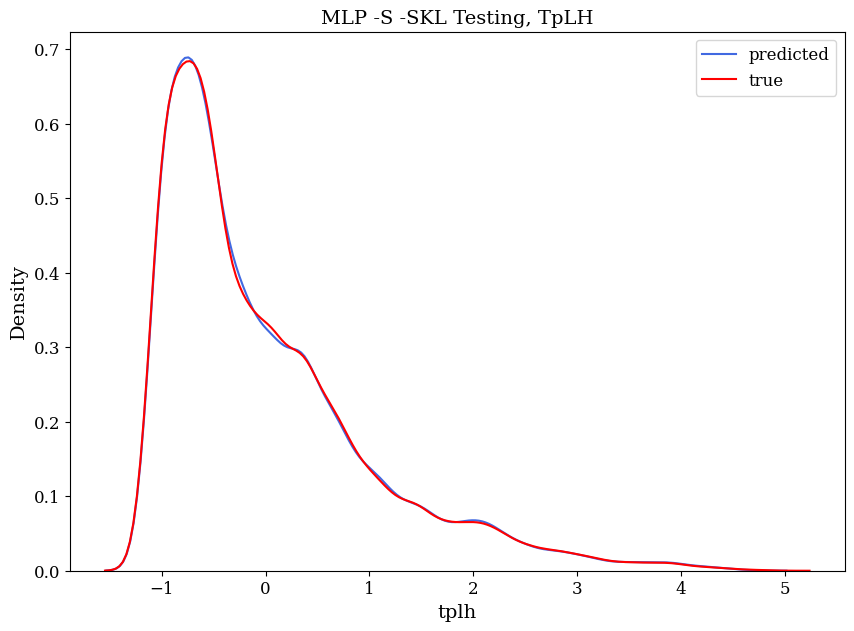

In [30]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc['tplh'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Testing, TpLH')
plt.savefig(f"{plots_dir}/MLP_S_SKL_TEST_TPLH.png")
ax.legend()
plt.show()
plt.close()

#### Predicting Energy

In [31]:
# Training
mlp_regressor.fit(X_train_sc, y_train_sc['iint'])

Iteration 1, loss = 0.15235138
Validation score: 0.906408
Iteration 2, loss = 0.02729838
Validation score: 0.969404
Iteration 3, loss = 0.01066843
Validation score: 0.985047
Iteration 4, loss = 0.00559104
Validation score: 0.991362
Iteration 5, loss = 0.00354643
Validation score: 0.993767
Iteration 6, loss = 0.00268264
Validation score: 0.995150
Iteration 7, loss = 0.00219327
Validation score: 0.995740
Iteration 8, loss = 0.00189123
Validation score: 0.996357
Iteration 9, loss = 0.00167856
Validation score: 0.996766
Iteration 10, loss = 0.00152684
Validation score: 0.997037
Iteration 11, loss = 0.00141017
Validation score: 0.997164
Iteration 12, loss = 0.00133038
Validation score: 0.997285
Iteration 13, loss = 0.00123796
Validation score: 0.997593
Iteration 14, loss = 0.00119708
Validation score: 0.997565
Iteration 15, loss = 0.00116758
Validation score: 0.997792
Iteration 16, loss = 0.00114618
Validation score: 0.997817
Iteration 17, loss = 0.00110628
Validation score: 0.997757
Iterat

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [32]:
print(mlp_regressor.out_activation_)
print(mlp_regressor.loss_)

identity
0.0009523914103849731


In [33]:
# Validation
y_pred_sc = mlp_regressor.predict(X_val_sc)

In [34]:
# Validation R² score
mlp_regressor.score(X_val_sc, y_val_sc['iint'])

0.9980962556050871

In [35]:
# Validation error
rmse = root_mean_squared_error(y_val_sc['iint'], y_pred_sc)
mse = mean_squared_error(y_val_sc['iint'], y_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.043603618442035995
clf: MLP, MSE 0.0019012755412386618


In [36]:
score(mlp_regressor, X_val_sc, y_val_sc['iint'], 'mlp_S_SKL', 'corrent', 'val')

{'r2': 0.9980962556050871,
 'rmse': 0.043603618442035995,
 'mse': 0.0019012755412386618}

In [37]:
# Testing
y_test_pred_sc = mlp_regressor.predict(Xte_sc)

In [38]:
# Testing R² score
mlp_regressor.score(Xte_sc, yte_sc['iint'])

0.9981114338162919

In [39]:
# Testing error
rmse = root_mean_squared_error(yte_sc['iint'], y_test_pred_sc)
mse = mean_squared_error(yte_sc['iint'], y_test_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.043540876721331515
clf: MLP, MSE 0.0018958079456621883


In [40]:
score(mlp_regressor, Xte_sc, yte_sc['iint'], 'mlp_S_SKL', 'corrent', 'test')

{'r2': 0.9981114338162919,
 'rmse': 0.043540876721331515,
 'mse': 0.0018958079456621883}

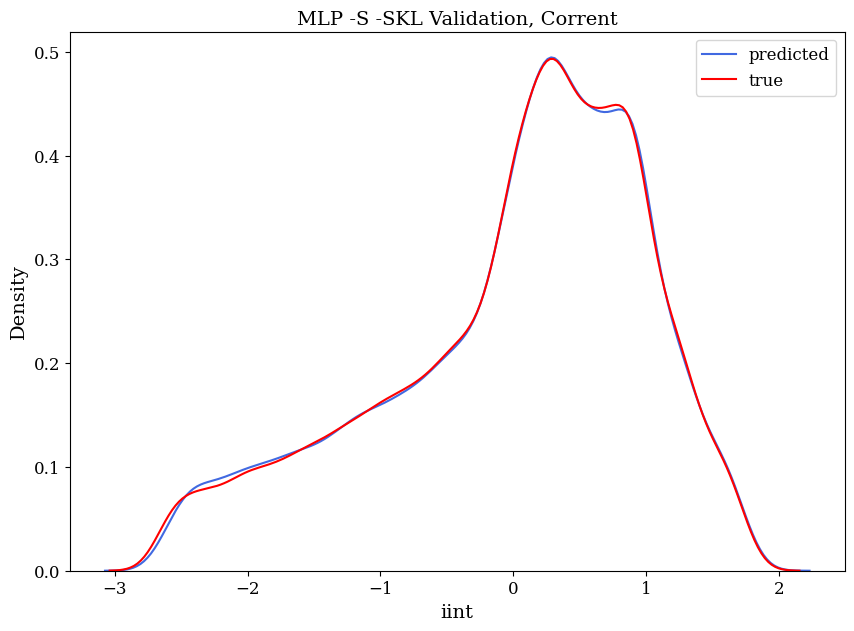

In [41]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc['iint'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, Corrent')
plt.savefig(f"{plots_dir}/MLP_S_SKL_VAL_CORRENT.png")
ax.legend()
plt.show()
plt.close()

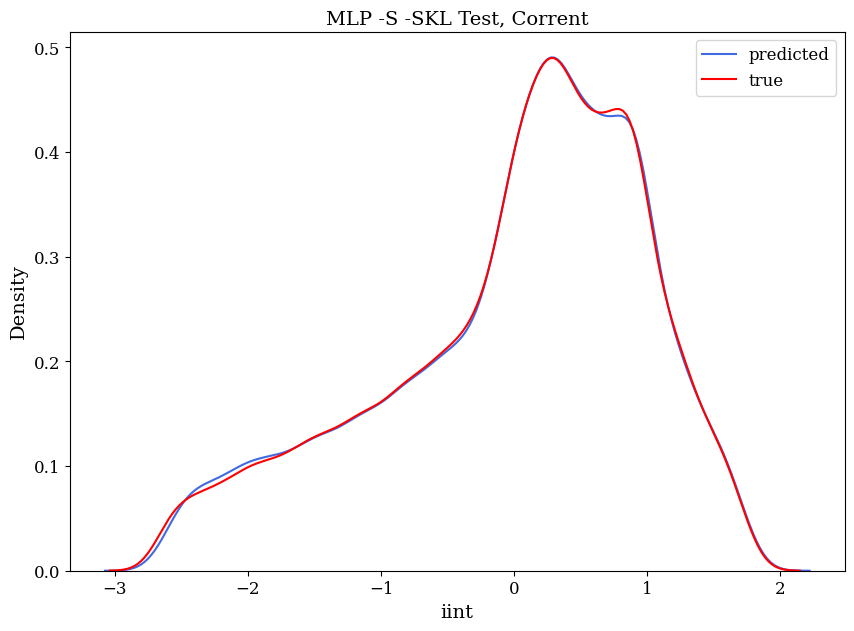

In [42]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['iint'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Test, Corrent')
plt.savefig(f"{plots_dir}/MLP_S_SKL_TEST_CORRENT.png")
ax.legend()
plt.show()
plt.close()

### Multi-output model

In [43]:
# Training
mlp_regressor.fit(X_train_sc, y_train_sc)

Iteration 1, loss = 0.16509695
Validation score: 0.891659
Iteration 2, loss = 0.03598445
Validation score: 0.952214
Iteration 3, loss = 0.01794609
Validation score: 0.974305
Iteration 4, loss = 0.01001788
Validation score: 0.985005
Iteration 5, loss = 0.00598511
Validation score: 0.990544
Iteration 6, loss = 0.00392209
Validation score: 0.993423
Iteration 7, loss = 0.00288223
Validation score: 0.994818
Iteration 8, loss = 0.00227964
Validation score: 0.995760
Iteration 9, loss = 0.00186894
Validation score: 0.996574
Iteration 10, loss = 0.00158069
Validation score: 0.996974
Iteration 11, loss = 0.00139297
Validation score: 0.997365
Iteration 12, loss = 0.00125835
Validation score: 0.997611
Iteration 13, loss = 0.00114812
Validation score: 0.997773
Iteration 14, loss = 0.00106569
Validation score: 0.997974
Iteration 15, loss = 0.00100220
Validation score: 0.998054
Iteration 16, loss = 0.00094876
Validation score: 0.998132
Iteration 17, loss = 0.00091445
Validation score: 0.998176
Iterat

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [44]:
print(mlp_regressor.out_activation_)
print(mlp_regressor.loss_)

identity
0.0007001388201414206


In [45]:
# Validation
y_pred_sc = mlp_regressor.predict(X_val_sc)

In [46]:
# Validation R² score
mlp_regressor.score(X_val_sc, y_val_sc)

0.9985961682867185

In [47]:
# Validation error
rmse = root_mean_squared_error(y_val_sc, y_pred_sc)
mse = mean_squared_error(y_val_sc, y_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.03595639518954292
clf: MLP, MSE 0.0013953278831484101


In [48]:
score(mlp_regressor, X_val_sc, y_val_sc, 'mlp_M_SKL', 'all', 'val')

{'r2': 0.9985961682867185,
 'rmse': 0.03595639518954292,
 'mse': 0.0013953278831484101}

In [49]:
# Testing
y_test_pred_sc = mlp_regressor.predict(Xte_sc)

In [50]:
# Testing R² score
mlp_regressor.score(Xte_sc, yte_sc)

0.9985881546348371

In [51]:
# Testing error
rmse = root_mean_squared_error(yte_sc, y_test_pred_sc)
mse = mean_squared_error(yte_sc, y_test_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.0363835884256544
clf: MLP, MSE 0.0014175790453814317


In [52]:
score(mlp_regressor, Xte_sc, yte_sc, 'mlp_M_SKL', 'all', 'test')

{'r2': 0.9985881546348371,
 'rmse': 0.0363835884256544,
 'mse': 0.0014175790453814317}

In [53]:
#scatter_plot_multi_output_regression_results(y_pred_sc, y_val_sc, variables, "MLP_M_SKL_VAL_ALL_SCATTER", "MLP_M_SKL_VAL_ALL_SCATTER")

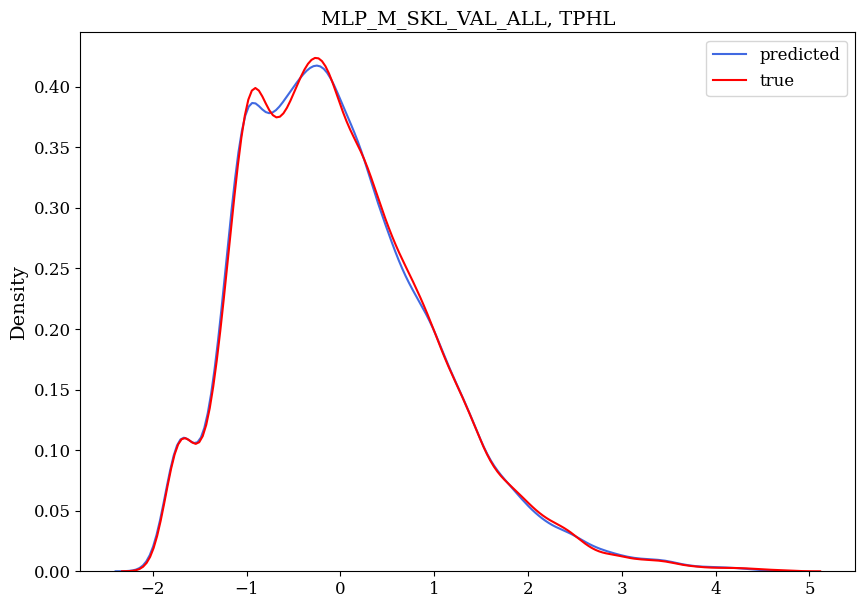

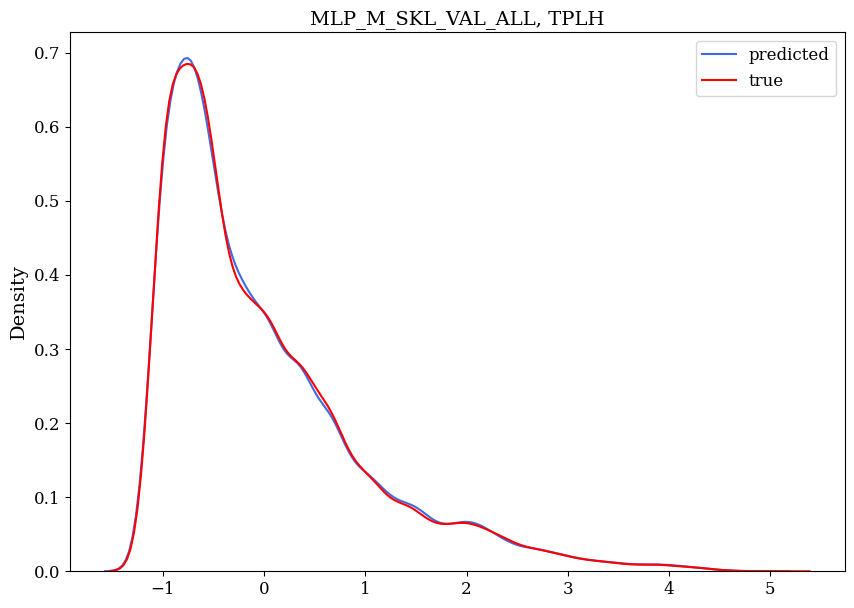

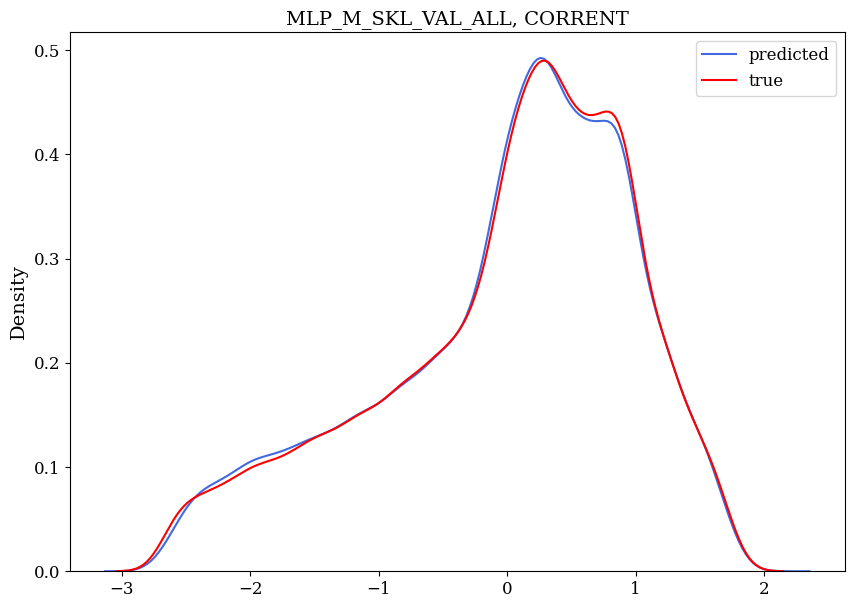

In [54]:
kde_plot_multi_output_regression_results(y_pred_sc, y_val_sc, variables, "MLP_M_SKL_VAL_ALL", "MLP_M_SKL_VAL_ALL")

In [55]:
# scatter_plot_multi_output_regression_results(y_test_pred_sc, yte_sc, variables, "MLP_M_SKL_TEST_ALL_SCATTER", "MLP_M_SKL_TEST_ALL_SCATTER")

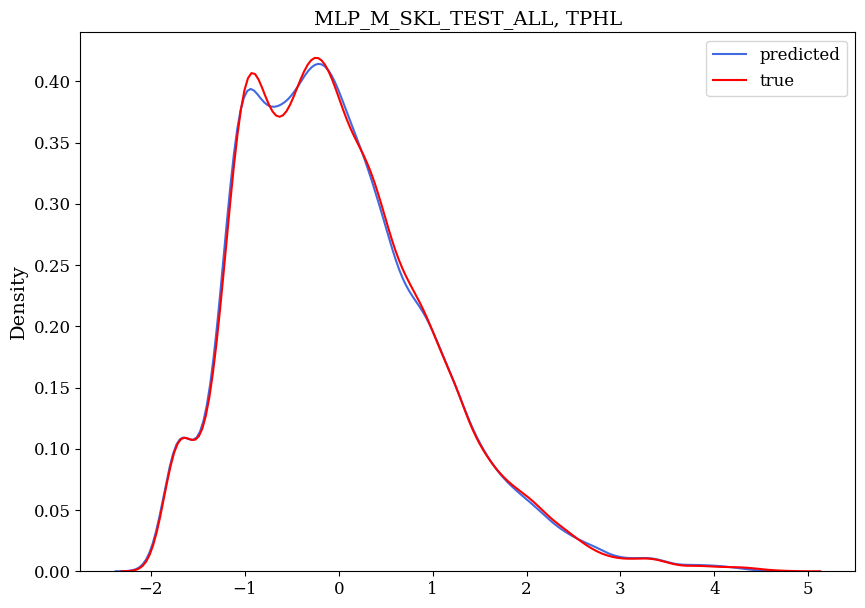

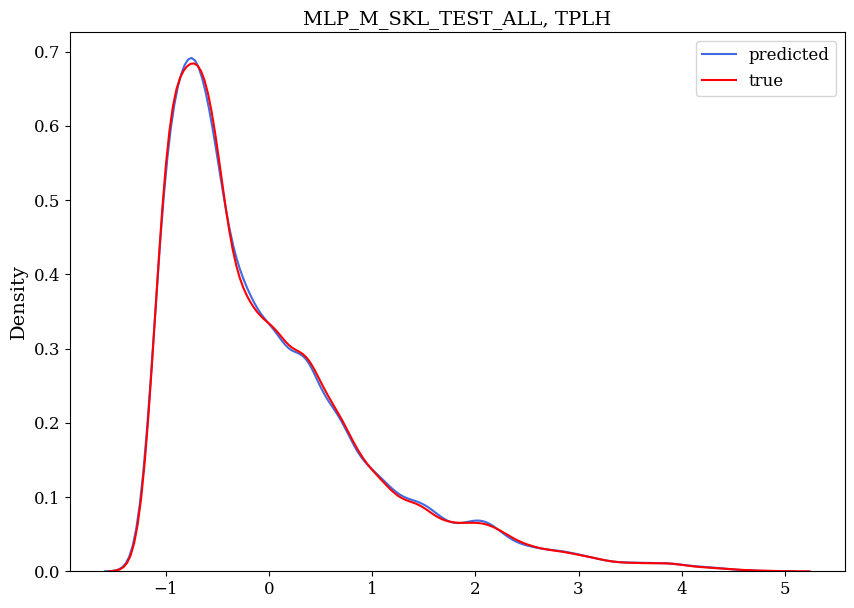

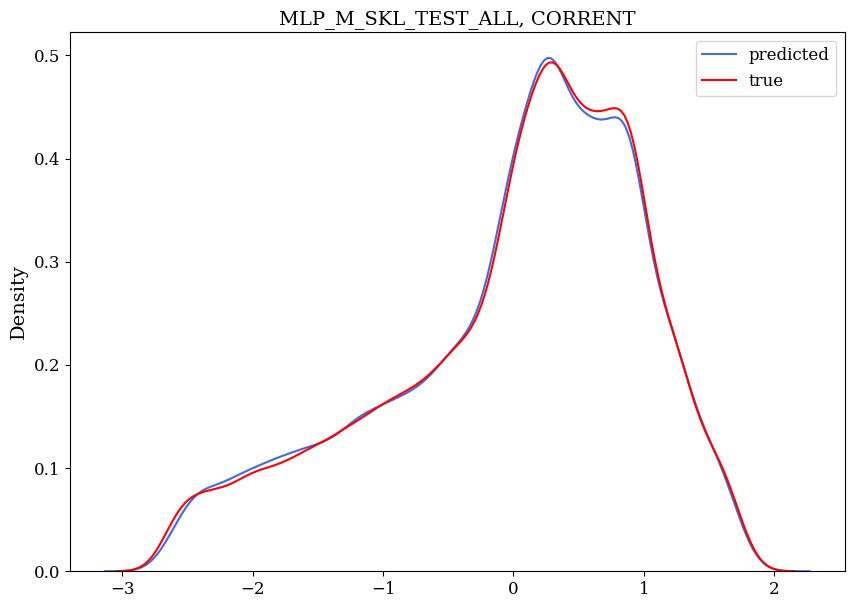

In [56]:
kde_plot_multi_output_regression_results(y_test_pred_sc, yte_sc, variables, "MLP_M_SKL_TEST_ALL", "MLP_M_SKL_TEST_ALL")

## Multi-layer Perceptron for Regression using Keras

Use test set and evaluate()

In [57]:
import tensorflow as tf
from tensorflow import keras

In [58]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

E0000 00:00:1776984263.138810   43373 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776984263.139071   43418 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776984263.152228   43373 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### Single-output models

In [59]:
model = tf.keras.models.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape=X_train_sc.shape[1:]),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(1)
])

/home/eduarda/jupyter_ic/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Predicting TPHL

In [60]:
K.clear_session()
model.compile(loss="mean_squared_error", optimizer="adam")
history = model.fit(X_train_sc, y_train_sc['tphl'], epochs=500, batch_size=32, validation_data=(X_val_sc, y_val_sc['tphl']),
                    shuffle=True, callbacks=[early_stop])

Epoch 1/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 901us/step - loss: 0.0317 - val_loss: 0.0016
Epoch 2/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 845us/step - loss: 0.0011 - val_loss: 8.3292e-04
Epoch 3/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 814us/step - loss: 9.0140e-04 - val_loss: 8.2491e-04
Epoch 4/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 924us/step - loss: 6.6548e-04 - val_loss: 7.3008e-04
Epoch 5/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 879us/step - loss: 6.2984e-04 - val_loss: 4.2059e-04
Epoch 6/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 897us/step - loss: 5.3327e-04 - val_loss: 6.9543e-04
Epoch 7/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 966us/step - loss: 4.9474e-04 - val_loss: 3.9685e-04
Epoch 8/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 894us/step - loss: 4.2311e-04 - val_loss: 3.2237e-04
Epoch 9/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 901us/step - loss: 4.2752e-04 - val_loss: 2.4662e-04
Epoch 10/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 924us/step - loss: 4.1477e-04 - val_loss: 2.5568e-04
Epoch 11/500
2007/200

In [61]:
ypred_sc = model.predict(X_val_sc)
mse = mean_squared_error(y_val_sc['tphl'], ypred_sc)
rmse = root_mean_squared_error(y_val_sc['tphl'], ypred_sc)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')

989/989 ━━━━━━━━━━━━━━━━━━━━ 0s 434us/step
clf: ANN, rmse: 0.008727747343258326
clf: ANN, mse: 7.617357368775277e-05


In [62]:
r2 = r2_score(y_val_sc['tphl'], ypred_sc)
print(f'R²: {r2}')

R²: 0.999924078457545


In [63]:
score(model, X_val_sc, y_val_sc['tphl'], 'mlp_S_K', 'tphl', 'val')

989/989 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step


{'r2': 0.999924078457545,
 'rmse': 0.008727747343258326,
 'mse': 7.617357368775277e-05}

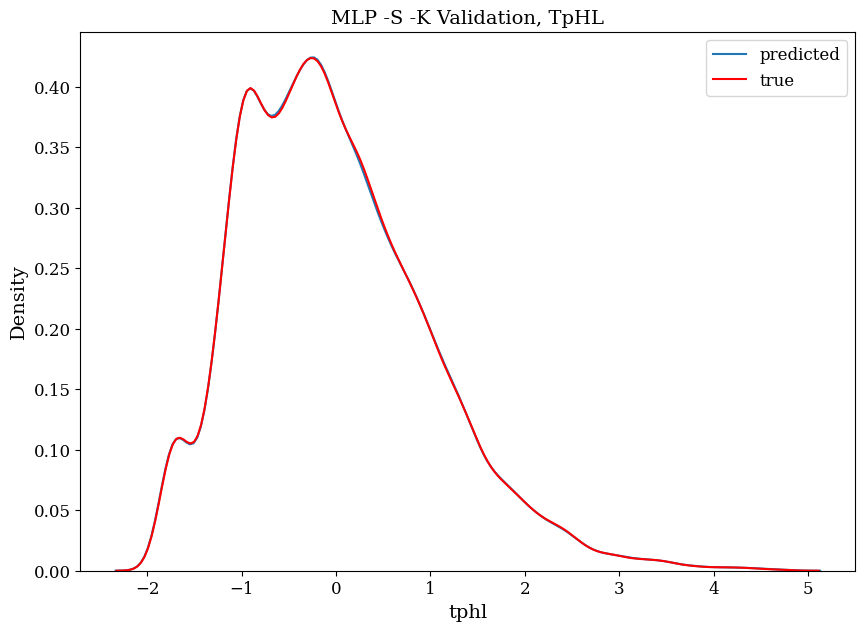

In [64]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=ypred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['tphl'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -K Validation, TpHL')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_K_VAL_TPHL.png")
plt.show()
plt.close()

#### Predicting TPLH

In [65]:
K.clear_session()
model.compile(loss="mean_squared_error", optimizer="adam")
history = model.fit(X_train_sc, y_train_sc['tplh'], epochs=500, batch_size=32, validation_data=(X_val_sc, y_val_sc['tplh']),
                    shuffle=True, callbacks=[early_stop])

Epoch 1/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0616 - val_loss: 0.0012
Epoch 2/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 937us/step - loss: 0.0011 - val_loss: 8.1388e-04
Epoch 3/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 9.4224e-04 - val_loss: 7.0397e-04
Epoch 4/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.9898e-04 - val_loss: 0.0012
Epoch 5/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 9.1411e-04 - val_loss: 0.0017
Epoch 6/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 996us/step - loss: 8.7489e-04 - val_loss: 6.8508e-04
Epoch 7/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2320e-04 - val_loss: 7.2921e-04
Epoch 8/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.2971e-04 - val_loss: 8.1594e-04
Epoch 9/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 957us/step - loss: 8.0385e-04 - val_loss: 9.2020e-04
Epoch 10/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 977us/step - loss: 8.0271e-04 - val_loss: 7.7845e-04
Epoch 11/500
2007/2007 ━━━━━━━━━━━━━━━━━━

In [66]:
ypred_sc = model.predict(X_val_sc)
mse = mean_squared_error(y_val_sc['tplh'], ypred_sc)
rmse = root_mean_squared_error(y_val_sc['tplh'], ypred_sc)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')

989/989 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step
clf: ANN, rmse: 0.034221316285127035
clf: ANN, mse: 0.001171098488286701


In [67]:
r2 = r2_score(y_val_sc['tplh'], ypred_sc)

print(f'R²: {r2}')

R²: 0.9987975570555202


In [68]:
score(model, X_val_sc, y_val_sc['tplh'], 'mlp_S_K', 'tplh', 'val')

989/989 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step


{'r2': 0.9987975570555202,
 'rmse': 0.034221316285127035,
 'mse': 0.001171098488286701}

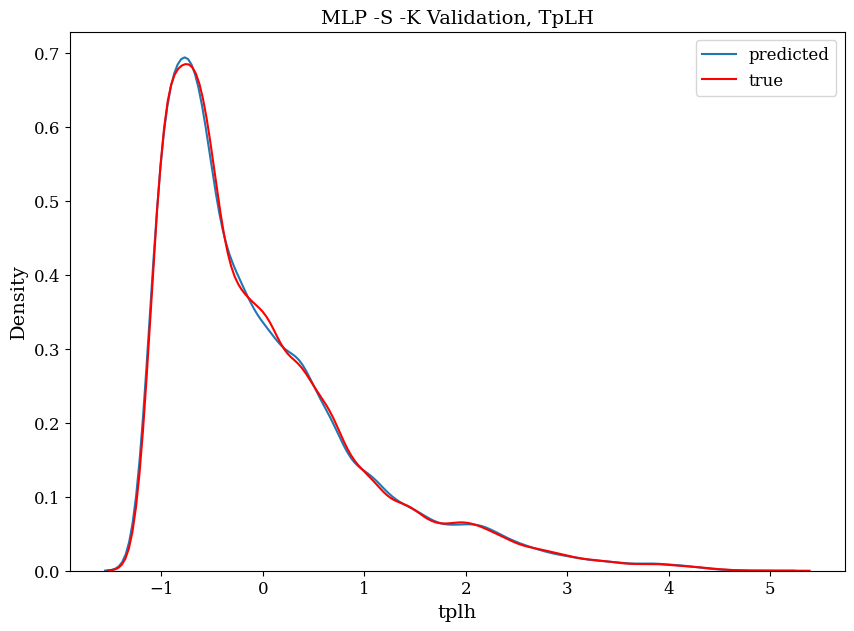

In [69]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=ypred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['tplh'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -K Validation, TpLH')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_K_VAL_TPLH.png")
plt.show()
plt.close()

#### Predicting Energy

In [70]:
K.clear_session()
model.compile(loss="mean_squared_error", optimizer="adam")
history = model.fit(X_train_sc, y_train_sc['iint'], epochs=500, batch_size=32, validation_data=(X_val_sc, y_val_sc['iint']),
                    shuffle=True, callbacks=[early_stop])

Epoch 1/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 960us/step - loss: 0.0636 - val_loss: 0.0040
Epoch 2/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 971us/step - loss: 0.0031 - val_loss: 0.0027
Epoch 3/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 978us/step - loss: 0.0025 - val_loss: 0.0025
Epoch 4/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 5/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 6/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 7/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0020 - val_loss: 0.0018
Epoch 8/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 939us/step - loss: 0.0019 - val_loss: 0.0017
Epoch 9/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 987us/step - loss: 0.0019 - val_loss: 0.0019
Epoch 10/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 923us/step - loss: 0.0018 - val_loss: 0.0022
Epoch 11/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 906us/step - loss: 0.0018 - val_loss: 0.0018
Epoch

In [71]:
ypred_sc = model.predict(X_val_sc)
mse = mean_squared_error(y_val_sc['iint'], ypred_sc)
rmse = root_mean_squared_error(y_val_sc['iint'], ypred_sc)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')

989/989 ━━━━━━━━━━━━━━━━━━━━ 0s 451us/step
clf: ANN, rmse: 0.0631824167371043
clf: ANN, mse: 0.003992017784741118


In [72]:
r2 = r2_score(y_val_sc['iint'], ypred_sc)
print(f'R²: {r2}')

R²: 0.9960027984806755


In [73]:
score(model, X_val_sc, y_val_sc['iint'], 'mlp_S_K', 'corrent', 'val')

989/989 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step


{'r2': 0.9960027984806755,
 'rmse': 0.0631824167371043,
 'mse': 0.003992017784741118}

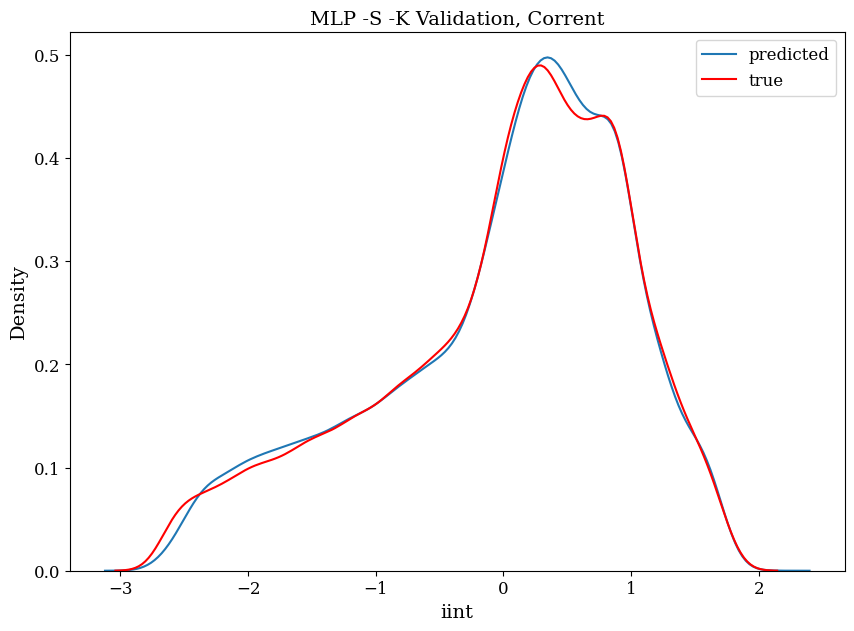

In [74]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=ypred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['iint'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -K Validation, Corrent')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_K_VAL_CORRENT.png")
plt.show()
plt.close()

### Multi-output model

In [75]:
model = tf.keras.models.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape=X_train_sc.shape[1:]),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(3)
])

K.clear_session()
model.compile(loss="mean_squared_error", optimizer="adam")
history = model.fit(X_train_sc, y_train_sc, epochs=500, batch_size=32, validation_data=(X_val_sc, y_val_sc), 
                    shuffle=True, callbacks=[early_stop])


/home/eduarda/jupyter_ic/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0448 - val_loss: 0.0033
Epoch 2/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 3/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 4/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 5/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 6/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 7/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 8/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 996us/step - loss: 0.0014 - val_loss: 0.0016
Epoch 9/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 10/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0013 - val_loss: 0.0021
Epoch 11/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 979us/step - loss: 0.0012 - val_loss: 0.0014
Epoch 12/500
20

In [76]:
ypred_sc = model.predict(X_val_sc)
mse = mean_squared_error(y_val_sc, ypred_sc)
rmse = root_mean_squared_error(y_val_sc, ypred_sc)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')

989/989 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step
clf: ANN, rmse: 0.05680513381958008
clf: ANN, mse: 0.00328808487392962


In [77]:
r2 = r2_score(y_val_sc, ypred_sc)

print(f'R²: {r2}')

R²: 0.9966917634010315


In [78]:
score(model, X_val_sc, y_val_sc, 'mlp_M_K', 'all', 'val')

989/989 ━━━━━━━━━━━━━━━━━━━━ 0s 402us/step


{'r2': 0.9966917634010315,
 'rmse': 0.05680513381958008,
 'mse': 0.00328808487392962}

In [79]:
variables = ['TPHL', 'TPLH', 'CORRENT']
#scatter_plot_multi_output_regression_results(ypred_sc, y_val_sc, variables, "MLP_M_K_VALL_ALL_SCATTER", "MLP_M_K_VALL_ALL_SCATTER")

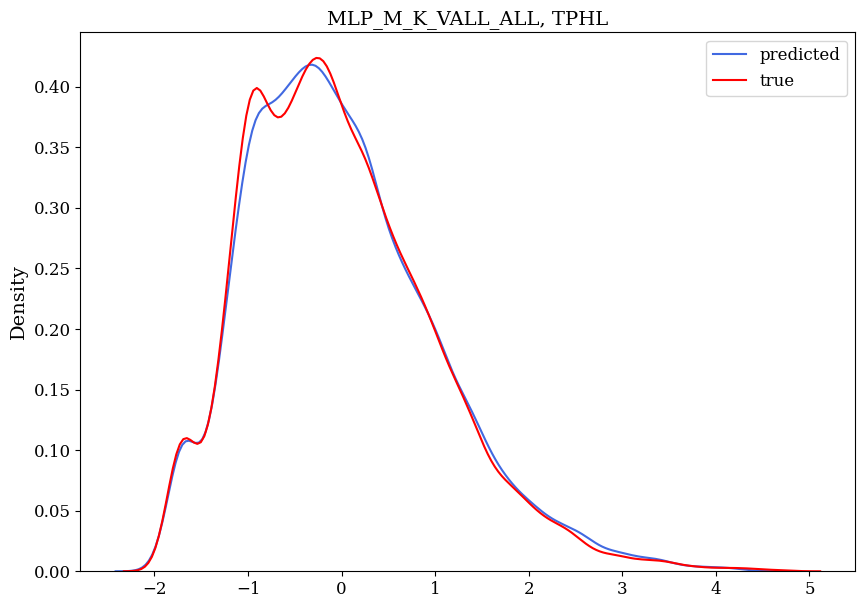

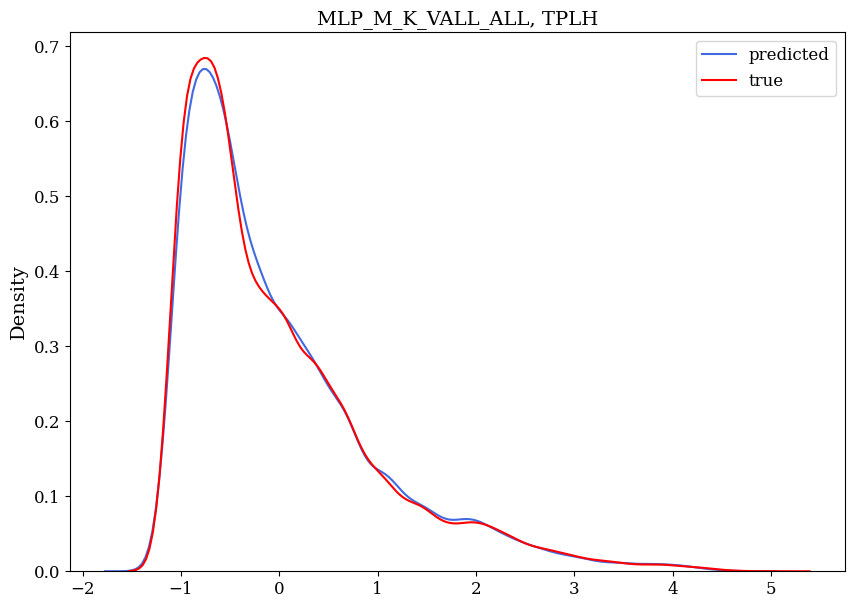

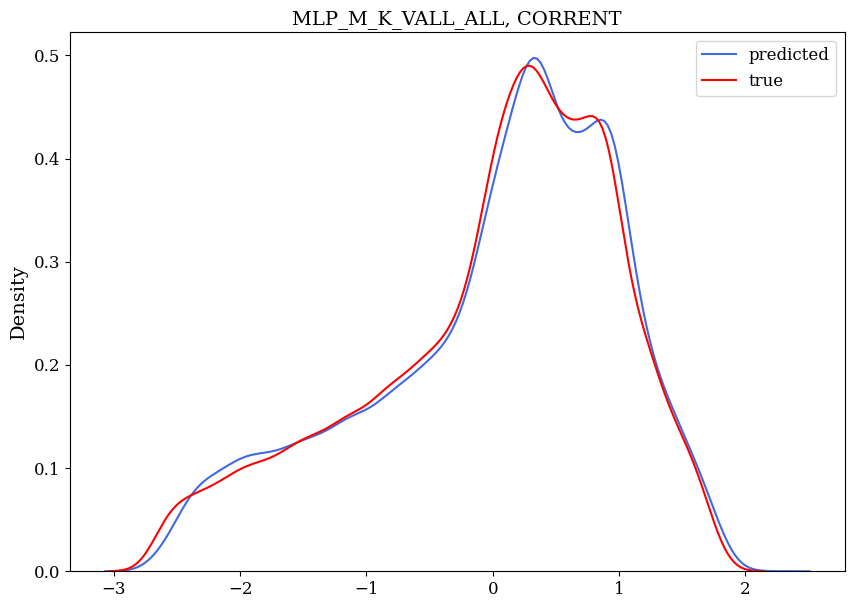

In [80]:
kde_plot_multi_output_regression_results(ypred_sc, y_val_sc, variables, "MLP_M_K_VAL_ALL", "MLP_M_K_VALL_ALL")

## Results

In [81]:
import os

results = pd.DataFrame.from_dict(scores, orient='index')
results.index.names = ['target', 'model', 'set']

path = os.path.join('../outputs/not_32nm_cmos', 'results_mlps')

results.to_csv(path, index_label='target_name')
results

r2      rmse       mse
target    model   set                               
mlp_S_SKL tphl    val   0.999656  0.018585  0.000345
                  test  0.999643  0.019030  0.000362
          tplh    val   0.999277  0.026539  0.000704
                  test  0.999275  0.026885  0.000723
          corrent val   0.998096  0.043604  0.001901
                  test  0.998111  0.043541  0.001896
mlp_M_SKL all     val   0.998596  0.035956  0.001395
                  test  0.998588  0.036384  0.001418
mlp_S_K   tphl    val   0.999924  0.008728  0.000076
          tplh    val   0.998798  0.034221  0.001171
          corrent val   0.996003  0.063182  0.003992
mlp_M_K   all     val   0.996692  0.056805  0.003288